# Event en ObsPy
## Índice
1. [Introducción](#1-introducción)
2. [Visualización de un Catálogo de Eventos](#2-visualizar)
3. [Extracción de información de un Evento](#3-información)
4. [Escritura de un Catálogo de Eventos](#4-escritura)
5. [Lectura de un Archivo NDK](#5-lectura-ndk)
6. [Uso de Event con datos sísmicos](#6-event-datos)
## 1. Introducción <a id="1-introducción"></a>
En ObsPy, un Event representa un evento sísmico, como un terremoto. Contiene información sobre el origen del evento, su magnitud, y otros detalles relacionados.

Los datos de eventos se pueden almacenar en formatos como QuakeML y NDK. ObsPy puede trabajar con ambos formatos.

Ejemplo de lectura de un archivo QuakeML:

In [1]:
from obspy import read_events

In [2]:
cat = read_events("C:/Users/Huawei/Desktop/Apoyo_docencia/Sismologia/Archivos/event/GCMT_2014_04_01__Mw_8_1.xml")
print(cat)

1 Event(s) in Catalog:
2014-04-01T23:47:31.500000Z | -19.700,  -70.810 | 8.1  Mwc


Para leer un archivo de eventos, se utiliza la función `read_events`.

## 2. Visualización de un Catálogo de Eventos <a id="2-visualizar"></a>
ObsPy permite visualizar la ubicación de los eventos en un mapa utilizando el método `plot`.

Ejemplo:

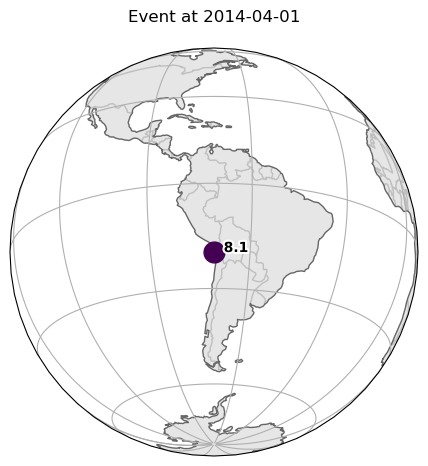

In [3]:
cat.plot(projection="ortho"); 

También se pueden filtrar eventos por profundidad o magnitud antes de graficarlos:

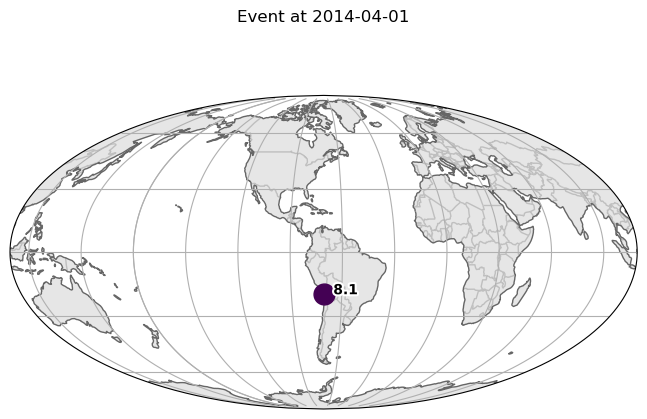

In [10]:
cat.filter("magnitude > 7").plot();

## 3. Extracción de información de un Evento <a id="3-información"></a>
Se puede acceder a la información detallada de un evento específico dentro del catálogo.

Ejemplo:

In [11]:
event = cat[0]
print(event)

Event:	2014-04-01T23:47:31.500000Z | -19.700,  -70.810 | 8.1  Mwc

	                  resource_id: ResourceIdentifier(id="smi:service.iris.edu/fdsnws/event/1/query?eventid=4597319")
	                   event_type: 'earthquake'
	          preferred_origin_id: ResourceIdentifier(id="smi:www.iris.edu/spudservice/momenttensor/gcmtid/C201404012346A#cmtorigin")
	 preferred_focal_mechanism_id: ResourceIdentifier(id="smi:ds.iris.edu/spudservice/momenttensor/gcmtid/C201404012346A/quakeml#focalmechanism")
	                         ---------
	           event_descriptions: 1 Elements
	             focal_mechanisms: 1 Elements
	                      origins: 2 Elements
	                   magnitudes: 1 Elements


Un Event contiene atributos como el origen (`origin`), la magnitud (`magnitude`), y otros detalles.

## 4. Escritura de un Catálogo de Eventos <a id="4-escritura"></a>
Para guardar un catálogo de eventos en un archivo, se utiliza el método `write`.

Ejemplo de escritura en formato QuakeML:

In [13]:
cat.write("temp_quake.xml", format="quakeml")

## 5. Lectura de un Archivo NDK <a id="5-lectura-ndk"></a>
Los archivos NDK son un formato común para almacenar datos de eventos sísmicos, especialmente en el catálogo GCMT.

Ejemplo de lectura de un archivo NDK:

In [14]:
cat = read_events("C:/Users/Huawei/Desktop/Apoyo_docencia/Sismologia/Archivos/event/2014.ndk")
print(cat)

2463 Event(s) in Catalog:
2014-04-01T01:59:46.300000Z | -34.990, -108.410 | 4.79 Mwc
2014-04-01T05:05:57.500000Z | +48.940, -129.570 | 5.07 Mwc
...
2014-09-30T22:34:31.500000Z | -17.850, -178.590 | 5.46 Mwc
2014-09-30T23:23:01.500000Z | +56.740,  -34.460 | 4.91 Mwc
To see all events call 'print(CatalogObject.__str__(print_all=True))'


Puedes filtrar eventos en un catálogo utilizando el método `filter`.

In [15]:
cat.filter("depth > 100000", "magnitude > 7")

2 Event(s) in Catalog:
2014-06-23T20:53:33.700000Z | +52.000, +178.430 | 7.92 Mwc
2014-11-01T18:57:29.900000Z | -19.760, -177.610 | 7.11 Mwc

## 6. Uso de Event con datos sísmicos <a id="6-event-datos"></a>

Un Event puede utilizarse para descargar datos sísmicos relacionados con un terremoto específico.

Ejemplo de descarga de datos para un evento:

In [16]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

1 Trace(s) in Stream:
IU.TUC.00.HH1 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples


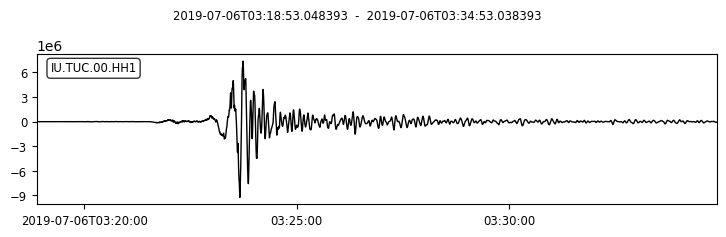

In [17]:
client = Client("IRIS")
time = UTCDateTime("2019-07-06T03:19:53.04")  # Tiempo de origen del terremoto
st = client.get_waveforms(network="IU", station="TUC", location="00", channel="HH1", 
                          starttime=time - 60, endtime=time + 60*15)
print(st)
st.plot();

Referencias:

Dybing, S. (2020). ObsPy Tutorial: Full Notebook [Jupyter Notebook]. En ROSES 2020: Research on Seismology. GitHub. https://github.com/roseseismo/roses2020/blob/main/unit01/Obspy_Tutorial_Full_Notebook.ipynb

Krischer, L. & Megies, T.. (2024). Introduction to file formats in ObsPy [Jupyter Notebook with solutions]. In skience2024: Seismology Course Materials. GitHub. https://github.com/heinerigel/skience2024/blob/main/00%20ObsPy%20Intro/01_File_Formats-with_solutions.ipynb